# 02 — PROSPECT-D/SAIL forward model demo

Builds a Look-Up Table (LUT) of simulated canopy reflectance spectra by sampling literature-standard PROSPECT-D/SAIL parameter ranges (`src/prospect_inversion.PARAMETER_RANGES`) and running the `prosail` package's forward model. Demonstrates the forward model against a real vegetation pixel from `01_tanager_load_and_preprocess.ipynb` as a plausibility check, before the full hyperspectral inversion in `03_hyperspectral_inversion.ipynb`.

See `REFERENCES.md` for PROSPECT-D (Féret et al. 2017) and 4SAIL (Verhoef et al. 2007) citations, and `src/prospect_inversion.py` for the LUT generation code.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, prospect_inversion as pi

## Load the same scene as notebook 01

Reuses the real scene geometry (solar zenith angle) to ground the LUT in this scene's actual viewing/illumination conditions rather than an arbitrary default.

In [2]:
SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")

scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
reflectance = scene.cube.copy()
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
reflectance[invalid_pixels] = np.nan

mean_sun_zenith = float(np.nanmean(scene.sun_zenith[~invalid_pixels]))
print(f"Scene mean solar zenith angle: {mean_sun_zenith:.1f} deg")

Scene mean solar zenith angle: 47.4 deg


## Generate the LUT

Latin hypercube sample of `PARAMETER_RANGES` (N, Cab, Car, Ant, Cw, Cm, LAI), forward-run through PROSPECT-D + SAIL via `prosail.run_prosail`, resampled onto the real Tanager wavelength grid. Canopy structure (leaf angle distribution, hotspot) and soil brightness are held at literature-standard defaults — this project's question is about biochemical parameter retrieval, not canopy structure retrieval.

In [3]:
N_LUT_SAMPLES = 5000

lut = pi.generate_lut(
    n_samples=N_LUT_SAMPLES,
    wavelengths=wavelengths,
    seed=42,
    tts=mean_sun_zenith,
    tto=0.0,   # near-nadir viewing
    psi=0.0,
)
print(f"LUT spectra shape: {lut['spectra'].shape}")
print(f"Parameters: {lut['parameter_names']}")

LUT spectra shape: (5000, 426)
Parameters: ['N', 'Cab', 'Car', 'Ant', 'Cw', 'Cm', 'LAI']


## Single forward-model spectrum

One example spectrum from the LUT, to sanity-check shape and amplitude against known leaf/canopy optical behaviour (green reflectance peak, red absorption trough, NIR plateau, SWIR water absorption features at 1450/1940 nm).

Example parameters: {'N': np.float64(1.032), 'Cab': np.float64(9.481), 'Car': np.float64(5.717), 'Ant': np.float64(6.417), 'Cw': np.float64(0.02), 'Cm': np.float64(0.007), 'LAI': np.float64(5.213)}


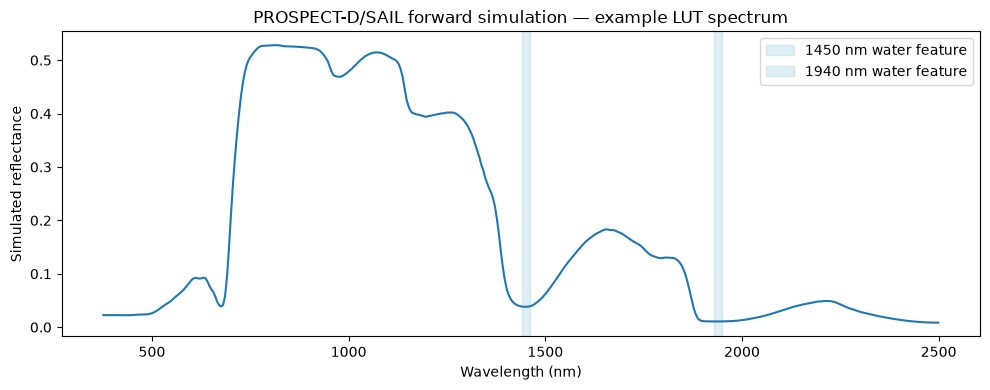

In [4]:
example_idx = 0
example_params = dict(zip(lut["parameter_names"], lut["parameters"][example_idx]))
example_spectrum = lut["spectra"][example_idx]

print("Example parameters:", {k: round(v, 3) for k, v in example_params.items()})

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wavelengths, example_spectrum)
ax.axvspan(1440, 1460, color="lightblue", alpha=0.4, label="1450 nm water feature")
ax.axvspan(1930, 1950, color="lightblue", alpha=0.4, label="1940 nm water feature")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Simulated reflectance")
ax.set_title("PROSPECT-D/SAIL forward simulation — example LUT spectrum")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/02_forward_example_spectrum.png", dpi=150)
plt.show()

## Plausibility check against a real vegetation pixel

Not a fitted inversion (that's notebook 03) — just overlaying the LUT's spectral envelope against one real, high-NDVI Tanager pixel to confirm the simulated spectra fall in a physically reasonable range for this scene.

Chosen high-NDVI pixel: (np.int64(0), np.int64(17)), NDVI=0.88


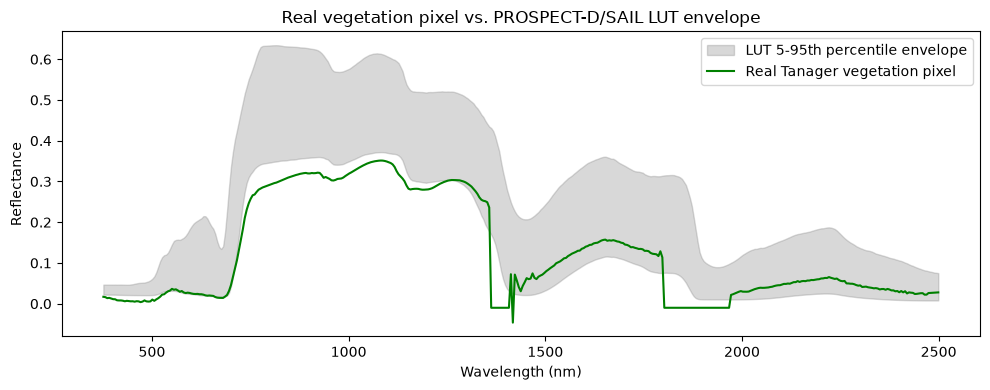

In [5]:
red_idx = int(np.argmin(np.abs(wavelengths - 650)))
nir_idx = int(np.argmin(np.abs(wavelengths - 840)))
ndvi = (reflectance[:, :, nir_idx] - reflectance[:, :, red_idx]) / (
    reflectance[:, :, nir_idx] + reflectance[:, :, red_idx] + 1e-6
)

veg_rows, veg_cols = np.where(np.nan_to_num(ndvi, nan=-1) > 0.7)
chosen = (veg_rows[0], veg_cols[0])
real_spectrum = reflectance[chosen[0], chosen[1], :]
print(f"Chosen high-NDVI pixel: {chosen}, NDVI={ndvi[chosen]:.2f}")

lut_lo = np.nanpercentile(lut["spectra"], 5, axis=0)
lut_hi = np.nanpercentile(lut["spectra"], 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(wavelengths, lut_lo, lut_hi, color="gray", alpha=0.3, label="LUT 5-95th percentile envelope")
ax.plot(wavelengths, real_spectrum, color="green", label="Real Tanager vegetation pixel")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.set_title("Real vegetation pixel vs. PROSPECT-D/SAIL LUT envelope")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/02_lut_vs_real_pixel.png", dpi=150)
plt.show()

**Observation:** the real pixel drops to near-zero/negative reflectance around ~1350-1400 nm and ~1780-1950 nm — this is expected, not a masking bug. Those are strong atmospheric water-vapour absorption bands where at-surface signal is heavily attenuated and surface-reflectance retrieval has very low SNR; they sit adjacent to (not inside) the 1450/1940 nm leaf-water-absorption features this project targets for Cw retrieval, so downstream inversion should treat this band range with reduced confidence or exclude it (revisited in `03_hyperspectral_inversion.ipynb`).

## Next steps

`03_hyperspectral_inversion.ipynb` uses `prospect_inversion.invert_lut` to fit LUT entries against real pixels, validated through a synthetic self-consistency test (this open dataset has no field-measured pigment ground truth).